In [1]:
from core.reader import load_experimental_data
from core.calculations import calculate_von_mises_stress


real_experiment_data_folder = r'D:\Users\complex_deformations\P29\experimental_vint'
real_experiment = load_experimental_data(real_experiment_data_folder)
real_experiment = calculate_von_mises_stress(
            real_experiment,
            s_x_col='S_TT',
            s_y_col='S_ZZ',
            s_xy_col='S_TZ',
            new_col_name='S_EQV'
        )

In [2]:
from core.reader import read_ansys_csv

numerical_experiment_data_biso = r"biso.csv"
numerical_experiment_biso = read_ansys_csv(numerical_experiment_data_biso)

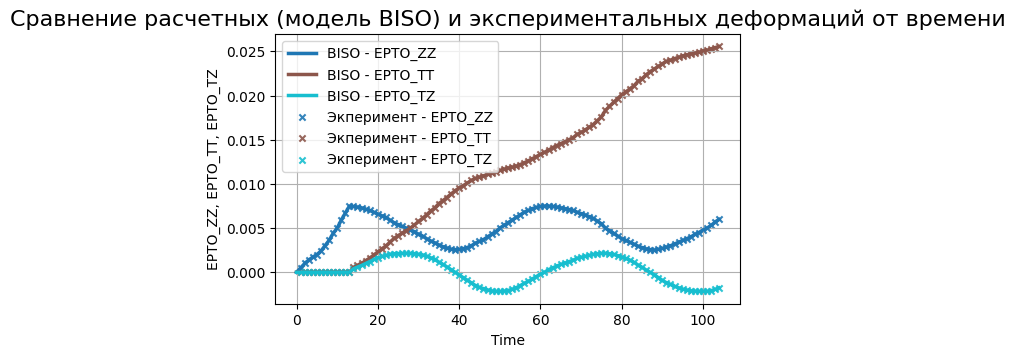

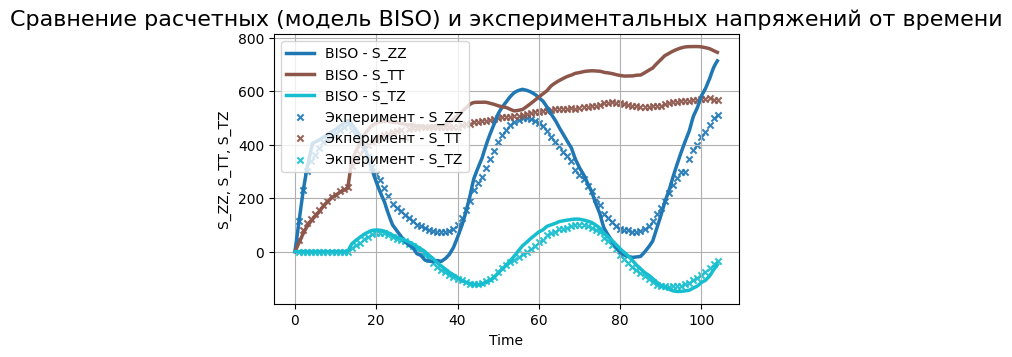

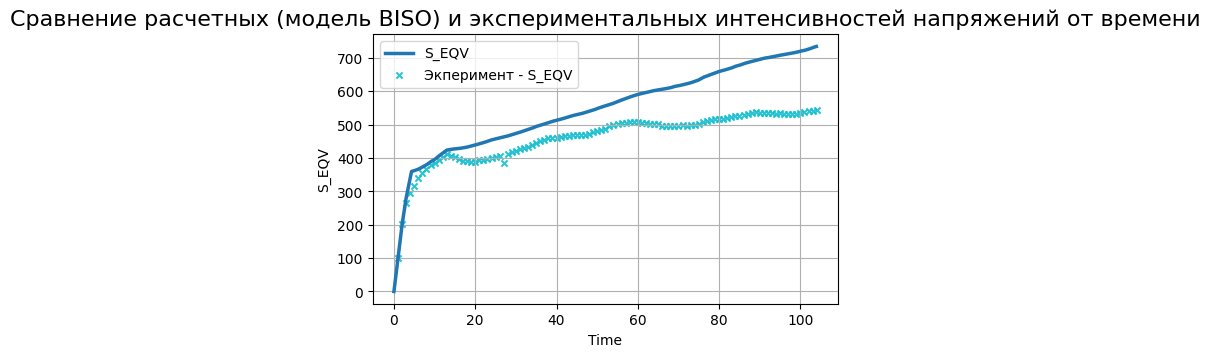

In [3]:
from core.visualizer import plot_xy

model_name = 'BISO'
plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    'Time',
    ['EPTO_ZZ', 'EPTO_TT', 'EPTO_TZ'],
    f'Сравнение расчетных (модель {model_name}) и экспериментальных деформаций от времени',
    ('Экперимент', real_experiment)
)

plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    'Time',
    ['S_ZZ', 'S_TT', 'S_TZ'],
    f'Сравнение расчетных (модель {model_name}) и экспериментальных напряжений от времени',
    ('Экперимент', real_experiment)
)

plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    'Time',
    ['S_EQV'],
    f'Сравнение расчетных (модель {model_name}) и экспериментальных интенсивностей напряжений от времени',
    ('Экперимент', real_experiment)
)

In [4]:
split_time = 14.0

Автоматически подобранные начальные приближения:
  p0 = 2.29e-04
  w0 = 0.1273
  b1 = 4.67e-06

Результат подгонки (FIT):
  Амплитуда (p): 2.14e-04
  Частота (w):   0.1280
  Фаза (phi):    0.6976
  Тренд (b1):    3.33e-06
  Сдвиг (b2):    4.30e-04


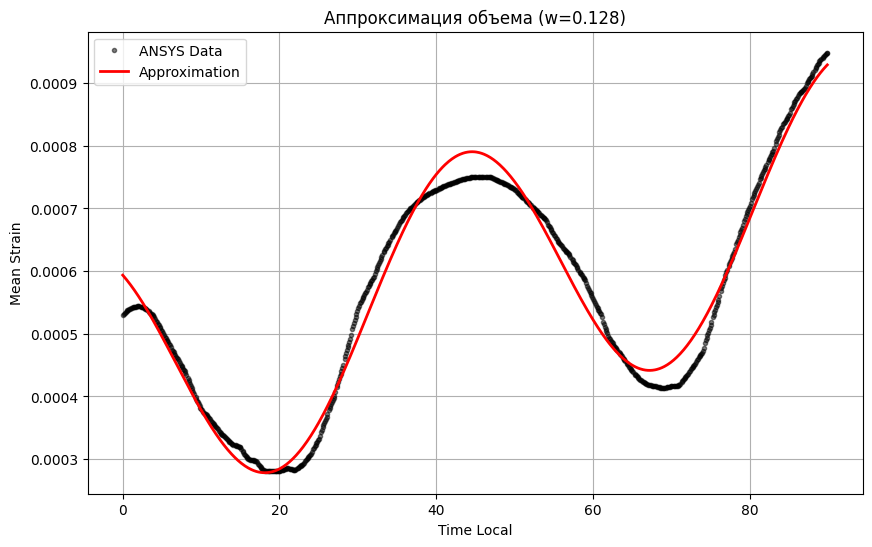

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


cols_needed = ['Time', 'EPTO_ZZ', 'EPTO_TT', 'EPTO_RR']
df_temp = numerical_experiment_biso[numerical_experiment_biso['Time'] > split_time][cols_needed].copy()
df_temp.reset_index(drop=True, inplace=True)
delta_ansys = (df_temp['EPTO_ZZ'] + df_temp['EPTO_TT'] + df_temp['EPTO_RR']) / 3.0
time_local = df_temp['Time'] - split_time

t_data = time_local.values
y_data = delta_ansys.values

# 2. Модель
def delta_model(t, p, w, phi, b1, b2):
    return p * np.cos(w * t + phi) + b1 * t + b2

# A. Оценка линейного тренда (b1, b2)
# Просто проводим линию через начало и конец
b1_guess = (y_data[-1] - y_data[0]) / (t_data[-1] - t_data[0])
b2_guess = np.mean(y_data)

# B. Оценка амплитуды (p)
# Вычитаем тренд и смотрим размах остатка
y_detrended = y_data - (b1_guess * t_data + b2_guess)
p_guess = (np.max(y_detrended) - np.min(y_detrended)) / 2.0

# C. Оценка частоты (w) через FFT (Преобразование Фурье)
# Это найдет доминирующую частоту колебаний автоматически
spectrum = np.fft.rfft(y_detrended)
frequencies = np.fft.rfftfreq(len(t_data), d=(t_data[1] - t_data[0]))
# Находим пик в спектре (пропускаем нулевую частоту)
peak_freq_idx = np.argmax(np.abs(spectrum[1:])) + 1
w_guess = 2 * np.pi * frequencies[peak_freq_idx]

print("Автоматически подобранные начальные приближения:")
print(f"  p0 = {p_guess:.2e}")
print(f"  w0 = {w_guess:.4f}")
print(f"  b1 = {b1_guess:.2e}")


p0 = [p_guess, w_guess, 0.0, b1_guess, b2_guess]

# bounds: ([min_p, min_w, ...], [max_p, max_w, ...])
try:
    popt, pcov = curve_fit(
        delta_model, t_data, y_data, 
        p0=p0,
        bounds=([0, 0, -np.pi, -np.inf, -np.inf], [np.inf, np.inf, np.pi, np.inf, np.inf])
    )
except RuntimeError:
    print("Не удалось найти параметры с ограничениями, пробуем без них...")
    popt, pcov = curve_fit(delta_model, t_data, y_data, p0=p0)


p_opt, w_opt, phi_opt, b1_opt, b2_opt = popt

print("\nРезультат подгонки (FIT):")
print(f"  Амплитуда (p): {p_opt:.2e}")
print(f"  Частота (w):   {w_opt:.4f}")
print(f"  Фаза (phi):    {phi_opt:.4f}")
print(f"  Тренд (b1):    {b1_opt:.2e}")
print(f"  Сдвиг (b2):    {b2_opt:.2e}")

plt.figure(figsize=(10, 6))
plt.plot(t_data, y_data, 'k.', label='ANSYS Data', alpha=0.5)
plt.plot(t_data, delta_model(t_data, *popt), 'r-', lw=2, label='Approximation')
plt.title(f'Аппроксимация объема (w={w_opt:.3f})')
plt.xlabel('Time Local')
plt.ylabel('Mean Strain')
plt.legend()
plt.grid(True)
plt.show()

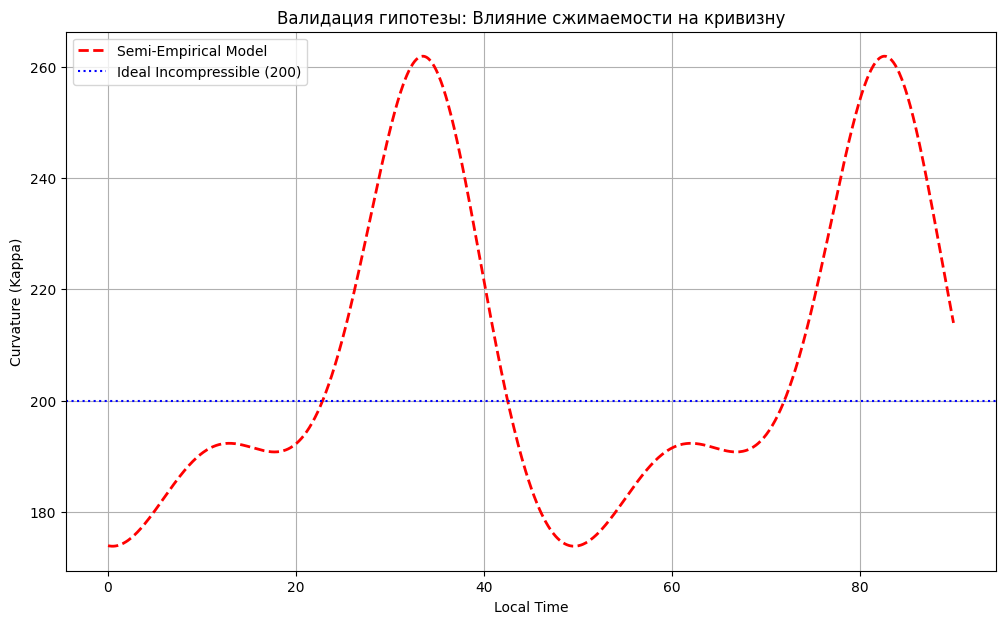

In [ ]:
def calculate_semi_empirical_curvature(t_array, delta_params, kinematic_omega, c=25e-4, a=157e-4):
    p, w_delta, phi, b1, b2 = delta_params
    
    w = w_delta 
    alpha = w * t_array
    
    sqrt3 = np.sqrt(3)
    
    # --- A. Идеальная кинематика (Несжимаемая, nu=0.5) ---
    # Скорости
    v_ez = -c * w * np.sin(alpha)
    v_et = ((sqrt3 * a * w) / (4 * np.pi)) + 0.5 * c * w * np.sin(alpha)
    v_etz = (sqrt3 / 2) * c * w * np.cos(alpha)
    
    # Ускорения
    a_ez = -c * (w**2) * np.cos(alpha)
    a_et = 0.5 * c * (w**2) * np.cos(alpha)
    a_etz = -(sqrt3 / 2) * c * (w**2) * np.sin(alpha)
    
    # --- B. Поправка на сжимаемость (Delta) ---
    # delta(t) = p*cos(wt+phi) + b1*t + b2
    # d_delta  = -p*w*sin(wt+phi) + b1
    # dd_delta = -p*w^2*cos(wt+phi)
    
    arg = w * t_array + phi
    d_delta = -p * w * np.sin(arg) + b1
    dd_delta = -p * (w**2) * np.cos(arg)
    
    # --- C. Сборка вектора Ильюшина ---
    # Ni_1 = eps_z - delta  =>  dNi_1 = v_ez - d_delta
    V1 = v_ez - d_delta
    A1 = a_ez - dd_delta
    
    # Ni_2 = 1/sqrt3 * (eps_z + 2*eps_theta - 3*delta)
    # Это равносильно: Ni_2(ideal) - sqrt(3)*delta
    # dNi_2 = v_ni2_ideal - sqrt(3)*d_delta
    
    # Считаем идеальную часть Ni_2
    v_ni2_ideal = (1/sqrt3) * (v_ez + 2*v_et)
    a_ni2_ideal = (1/sqrt3) * (a_ez + 2*a_et)
    
    # Добавляем поправку
    V2 = v_ni2_ideal - sqrt3 * d_delta
    A2 = a_ni2_ideal - sqrt3 * dd_delta
    
    # Ni_3 не зависит от объема
    V3 = (2/sqrt3) * v_etz
    A3 = (2/sqrt3) * a_etz
    
    # --- D. Расчет кривизны ---
    V = np.column_stack((V1, V2, V3))
    A = np.column_stack((A1, A2, A3))
    
    cross_prod = np.cross(V, A)
    num = np.linalg.norm(cross_prod, axis=1)
    den = np.linalg.norm(V, axis=1)**3
    
    return num / den

kappa_semi_emp = calculate_semi_empirical_curvature(time_local.values, popt, kinematic_omega=w_opt)

# Строим график сравнения
plt.figure(figsize=(12, 7))

# 1. ANSYS (Сплайн) - Голубая линия
# plt.plot(time_local, df_stage2['kappa_spline'], 'c-', linewidth=3, alpha=0.6, label='ANSYS (Numeric Spline)')

# 2. полуэмпирическая формула - Красная пунктирная
plt.plot(time_local, kappa_semi_emp, 'r--', linewidth=2, label='Semi-Empirical Model')

# 3. Идеал (Несжимаемый) - Синяя линия
plt.axhline(200, color='b', linestyle=':', label='Ideal Incompressible (200)')

plt.title('Валидация гипотезы: Влияние сжимаемости на кривизну')
plt.xlabel('Local Time')
plt.ylabel('Curvature (Kappa)')
plt.legend()
plt.grid(True)
plt.show()